# Punto 3 — Cómo se relaciona cada serie con sus valores anteriores

Se estudian las cuatro series del punto 1: viajes en bicicleta, temperatura, humedad y precipitación. Se comparan los datos originales con las diferencias propuestas en el punto 2.

## ¿Qué significan estos gráficos?

Un **rezago** es una distancia en el tiempo. Como los datos son diarios, el rezago 1 compara un día con el anterior y el rezago 7 compara un día con el mismo día de la semana anterior.

- **FAS o FAC (autocorrelación simple):** indica cuánto se relacionan los valores de una serie con sus valores anteriores. Un valor cercano a 1 indica una relación positiva fuerte; cercano a −1, una relación negativa fuerte; cercano a 0, poca relación lineal.
- **FACP (autocorrelación parcial):** mide la relación con un rezago después de descontar la relación que pasa por los días intermedios. Por ejemplo, en el rezago 2 intenta separar la relación directa de hoy con anteayer de la que se explica por ayer.
- **Autocovarianza (FACov):** también mide cómo varían juntos los valores separados por un rezago, pero depende de la escala de cada variable. Por eso no conviene comparar directamente su tamaño entre viajes y temperatura.

La consigna no define las siglas FAS y FAC. Aquí se usan como nombres de la autocorrelación simple y se agrega la autocovarianza como complemento. Cada figura reúne los tres gráficos, con sus nombres completos.

## ¿Qué permite inferir la teoría?

Una serie es **estacionaria** si mantiene una media y una variabilidad estables, y si la relación entre dos observaciones depende de la distancia temporal entre ellas, no de la fecha.

Los gráficos ayudan a proponer modelos:

- En un modelo **AR(p)**, el valor de hoy depende de los últimos p valores. Si el modelo es estacionario, la FACP teórica se vuelve cero después del rezago p y la FAC disminuye de forma gradual.
- En un modelo **MA(q)**, el valor de hoy depende de los últimos q errores o sorpresas. La FAC teórica se vuelve cero después del rezago q. Si el modelo es invertible, es decir, si sus errores pueden recuperarse a partir de los valores observados, la FACP disminuye gradualmente.
- Un modelo **ARMA** combina ambos mecanismos. En general, sus dos funciones disminuyen gradualmente.

En datos reales, las barras no siguen estas reglas de manera perfecta. Por eso sirven como orientación y no alcanzan para elegir un modelo definitivo. Tampoco se deben aplicar esas reglas directamente a una serie que no sea estacionaria.

Las zonas sombreadas son **bandas de confianza aproximadas del 95%**. Una barra que queda fuera sugiere una correlación distinta de cero en ese rezago. Como se miran muchas barras, algunas pueden salir de la banda por azar. Esto no demuestra por sí solo que una serie sea o no estacionaria.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.stattools import acf, acovf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/bicicletas_rosario.csv').exists())
series = {}
for nombre, archivo, columna in [
    ('Viajes MBTB', 'bicicletas_rosario.csv', 'viajes'),
    ('Temperatura', 'temperatura_rosario.csv', 't2m_c'),
    ('Humedad', 'humedad_rosario.csv', 'rh2m_pct'),
    ('Precipitación', 'precipitacion_rosario.csv', 'precip_mm')]:
    df = pd.read_csv(ROOT / 'data' / archivo, parse_dates=['fecha'])
    assert not df.fecha.duplicated().any(), 'Fechas duplicadas'
    s = df.set_index('fecha')[columna].sort_index().asfreq('D')
    assert s.notna().all() and np.isfinite(s).all(), 'Revisar faltantes o valores no finitos'
    series[nombre] = s
panel = pd.DataFrame(series)
assert panel.notna().all().all(), 'Series con fechas diferentes'
display(pd.DataFrame({'n': panel.count(), 'inicio': panel.index.min(), 'fin': panel.index.max()}))
variantes = {}
for nombre, s in series.items():
    variantes[nombre] = {'Nivel': s, 'Δ': s.diff().dropna()}
    if nombre == 'Viajes MBTB':
        variantes[nombre].update({'Δ7': s.diff(7).dropna(), 'ΔΔ7': s.diff().diff(7).dropna()})
    elif nombre in ('Temperatura', 'Humedad'):
        variantes[nombre]['Δ365'] = s.diff(365).dropna()


,n,inicio,fin
Viajes MBTB,1096,2023-01-01,2025-12-31
Temperatura,1096,2023-01-01,2025-12-31
Humedad,1096,2023-01-01,2025-12-31
Precipitación,1096,2023-01-01,2025-12-31


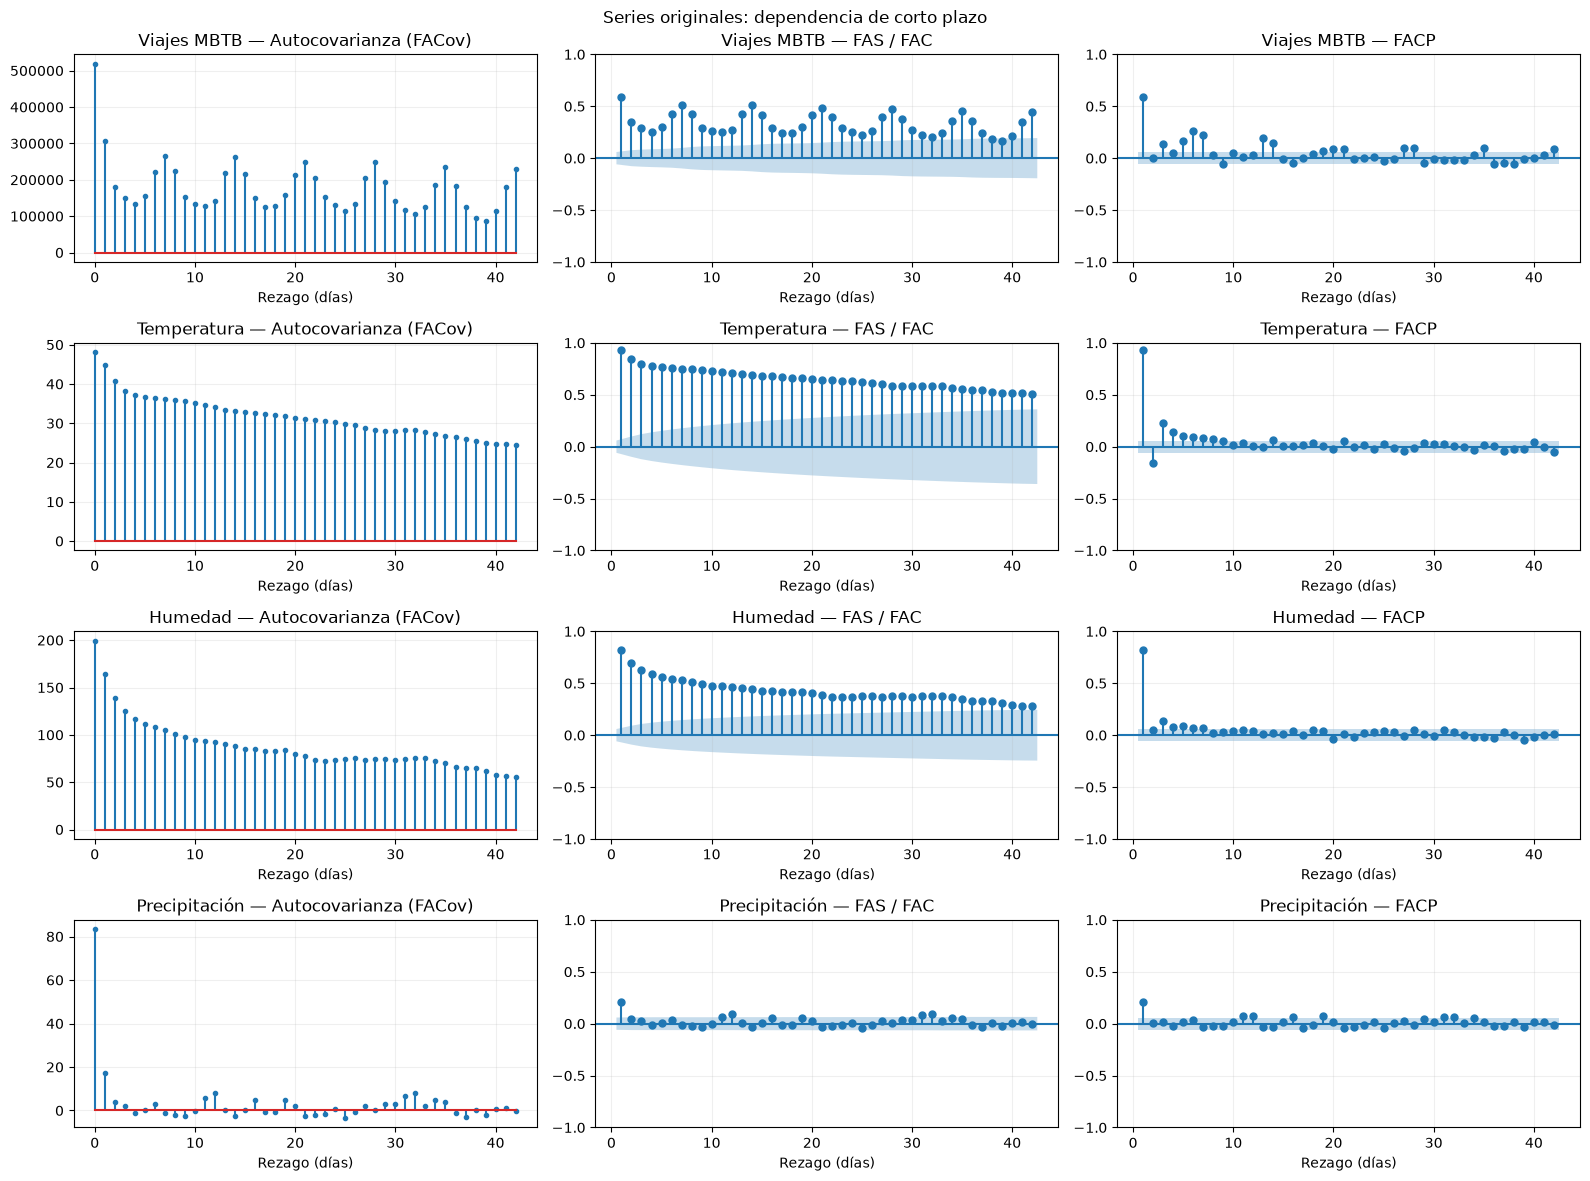

In [2]:
def correlogramas(conjunto, titulo, lags=42):
    fig, axes = plt.subplots(len(conjunto), 3, figsize=(16, 3 * len(conjunto)), squeeze=False)
    for fila, (nombre, s) in zip(axes, conjunto.items()):
        k = min(lags, len(s) // 2 - 1)
        fila[0].stem(np.arange(k + 1), acovf(s, fft=True, adjusted=False, nlag=k), markerfmt='.')
        fila[0].set_title(f'{nombre} — Autocovarianza (FACov)')
        plot_acf(s, lags=k, zero=False, ax=fila[1], title=f'{nombre} — FAS / FAC', alpha=.05)
        plot_pacf(s, lags=k, zero=False, method='ywm', ax=fila[2], title=f'{nombre} — FACP', alpha=.05)
        for ax in fila:
            ax.set_xlabel('Rezago (días)')
            ax.grid(alpha=.2)
    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()
correlogramas(series, 'Series originales: dependencia de corto plazo')


## Relación entre días separados por un año

Los primeros gráficos muestran hasta 42 días de separación. Ahora se amplía la FAC hasta 400 días para observar posibles patrones anuales. La línea roja marca los 365 días.

Solo hay tres años de datos, por lo que las conclusiones sobre el ciclo anual deben ser prudentes. Además, 365 días es una aproximación al año calendario: el período incluye un año bisiesto.

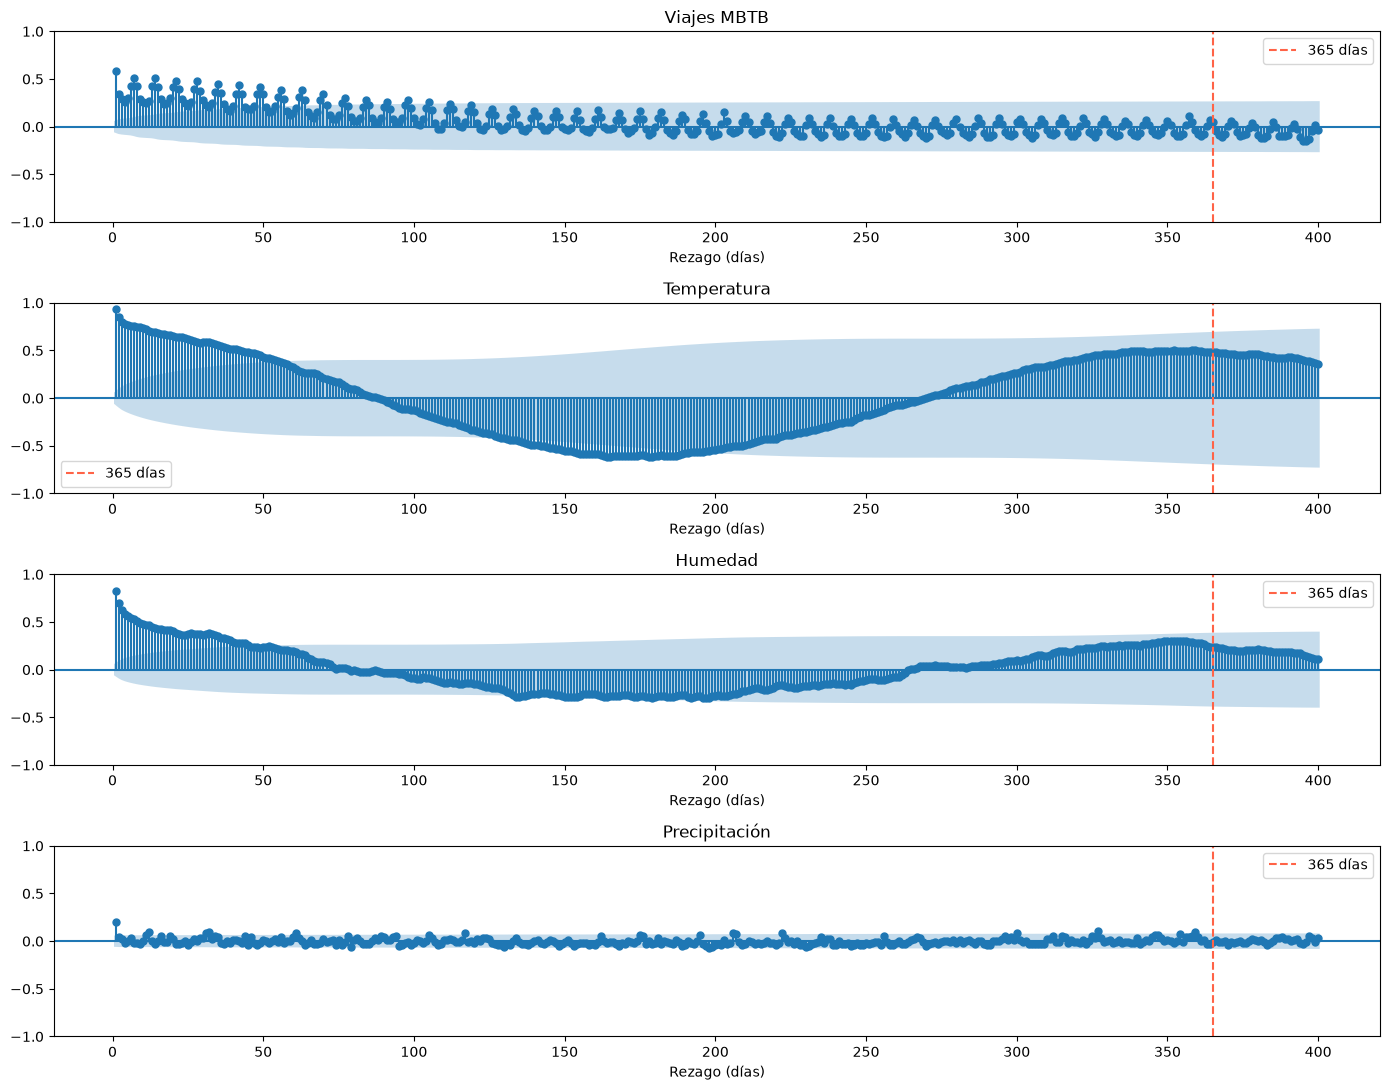

,Viajes MBTB,Temperatura,Humedad,Precipitación
Rezago,,,,
1,0.588,0.932,0.824,0.206
7,0.510,0.752,0.529,-0.016
30,0.276,0.584,0.367,0.037
182,0.158,-0.601,-0.273,-0.026
365,0.047,0.486,0.243,-0.014


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 11))
for ax, (nombre, s) in zip(axes, series.items()):
    plot_acf(s, lags=400, zero=False, ax=ax, title=nombre)
    ax.axvline(365, color='tomato', linestyle='--', label='365 días')
    ax.set_xlabel('Rezago (días)')
    ax.legend()
fig.tight_layout()
plt.show()
display(pd.DataFrame({nombre: acf(s, nlags=365)[[1, 7, 30, 182, 365]] for nombre, s in series.items()}, index=[1,7,30,182,365]).rename_axis('Rezago').round(3))


## ¿Qué cambia al calcular diferencias?

**Diferenciar** significa restar un valor anterior al valor actual:

- **Nivel:** dato original, sin restar nada.
- **Δ:** valor de hoy menos el de ayer.
- **Δ7:** valor de hoy menos el de hace siete días.
- **Δ365:** valor de hoy menos el de hace 365 días.
- **ΔΔ7:** primero se calcula la diferencia diaria y después se aplica la diferencia de siete días.

Se comparan estas opciones con los datos originales. La diferencia diaria de precipitación se incluye para observar qué sucede cuando se diferencia una serie que quizá no lo necesita.

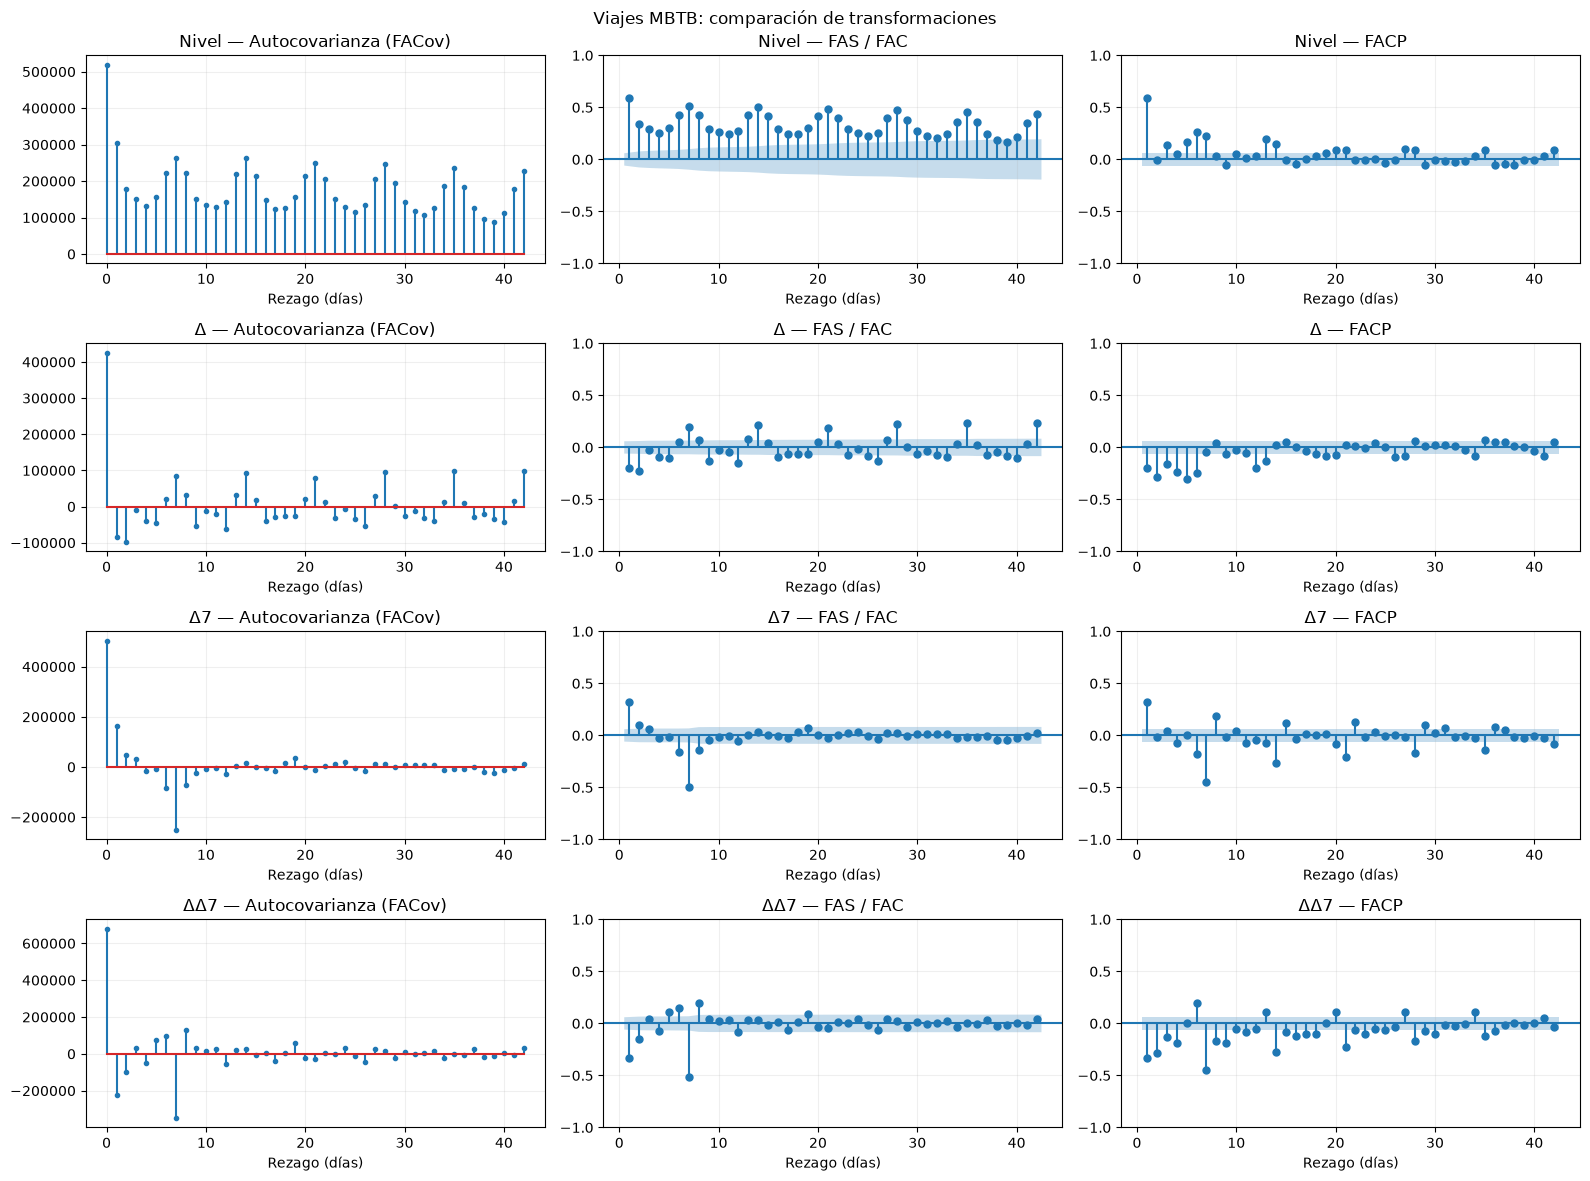

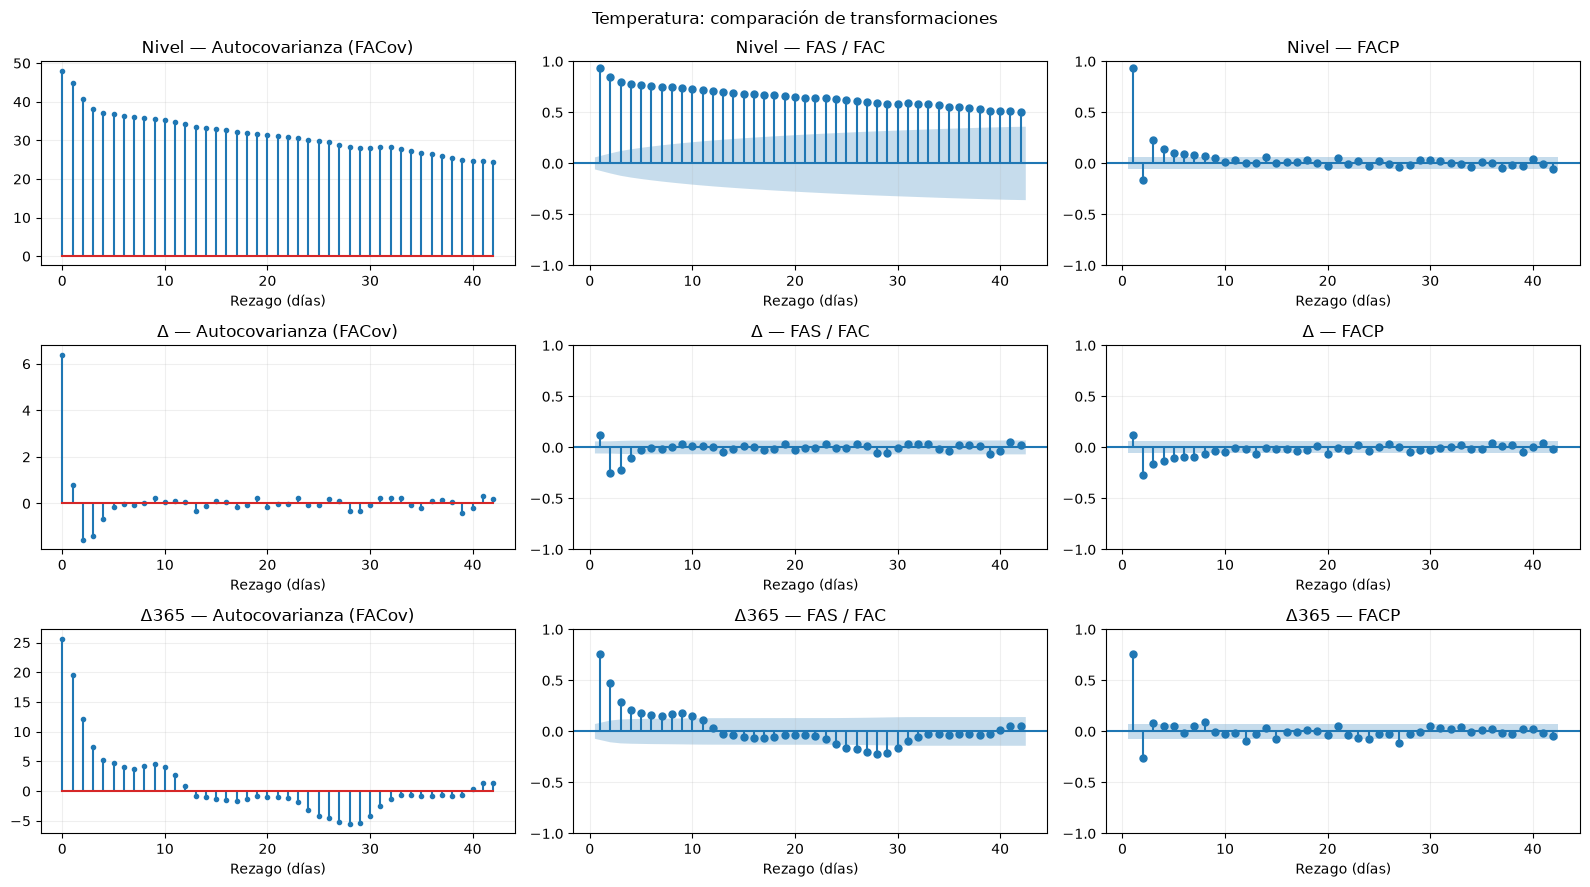

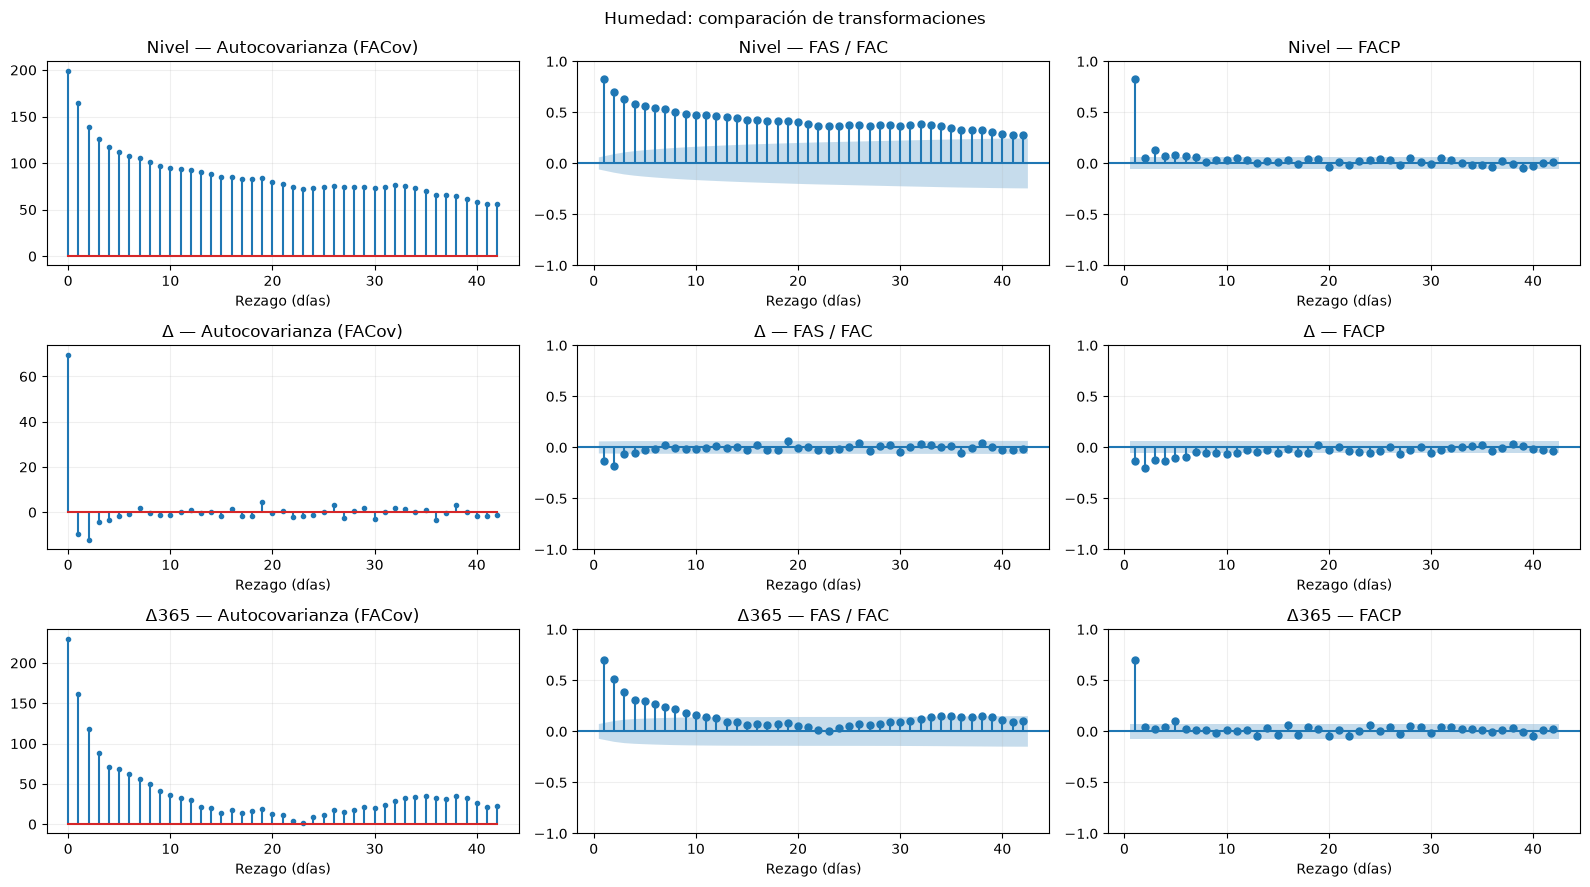

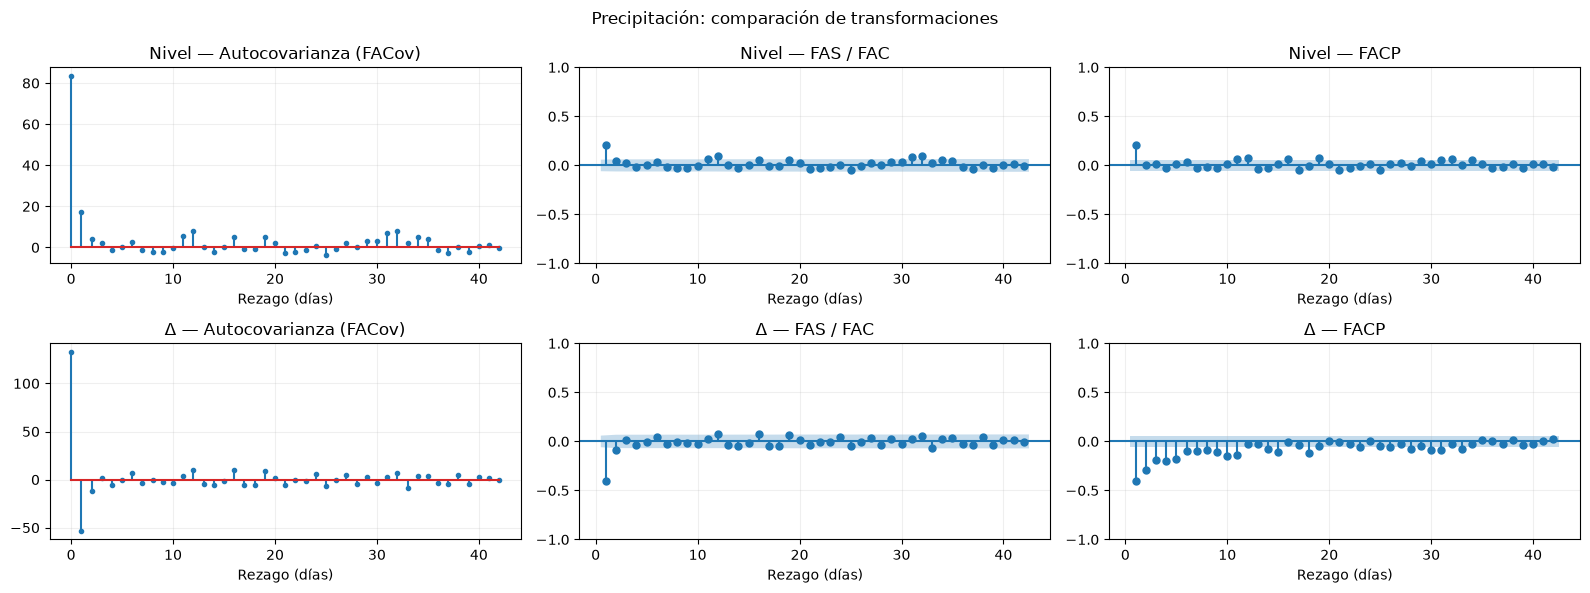

In [4]:
for nombre, conjunto in variantes.items():
    correlogramas(conjunto, nombre + ': comparación de transformaciones')


## Interpretación de los resultados

**Viajes en bicicleta.** La correlación es de aproximadamente 0,588 con el día anterior y 0,510 con el día de hace una semana. Esto indica que los viajes de un día guardan relación con los de días anteriores. Conviene estudiar tanto los cambios diarios como el patrón semanal. Después de restar el valor de hace siete días, la correlación en el rezago 7 queda cerca de −0,500. Esa relación negativa puede aparecer por la propia resta; no prueba que la diferencia semanal sea necesaria.

**Temperatura.** La correlación con el día anterior es muy alta: aproximadamente 0,932. A siete días sigue siendo alta, cerca de 0,752. Esto es razonable porque la temperatura suele cambiar gradualmente y sigue las estaciones del año. Esa persistencia no demuestra que sea necesario diferenciar. Incluso después de la diferencia anual queda una correlación de aproximadamente 0,761 con el día anterior. Una serie puede ser estacionaria y conservar relación entre días cercanos.

**Humedad.** La correlación es de aproximadamente 0,824 con el día anterior y 0,529 a siete días. Hay una relación temporal que el modelo debería tener en cuenta. La diferencia anual no garantiza que la serie se vuelva estacionaria; esto se revisa en el punto 4.

**Precipitación.** La correlación con el día anterior es de aproximadamente 0,206 y a siete días está cerca de cero (−0,016). La relación dura menos que en las otras series. Al calcular la diferencia diaria aparece una correlación negativa de aproximadamente −0,400 en el primer rezago. Esto sugiere que la resta podría ser innecesaria. Tener muchos días sin lluvia y algunos picos no demuestra, por sí solo, que la variabilidad cambie con el tiempo.

**Conclusión.** Los gráficos ayudan a reconocer patrones y a proponer modelos, pero no permiten elegir sus parámetros con certeza. Tampoco toda relación persistente exige diferenciar. El punto 4 agrega pruebas estadísticas para complementar esta lectura.

## Referencia

Statsmodels developers. (s. f.). *Time series analysis: API reference*. https://www.statsmodels.org/stable/tsa.html
